In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("tech_layoffs_2026_tracker.csv")

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
df.head()

Shape: (28, 26)

Data Types:
 company                           object
layoff_date                       object
jobs_cut                           int64
pct_workforce_cut                float64
sector                            object
country                           object
hq_city                           object
ai_cited                            bool
reason_stated                     object
company_revenue_2025_bn          float64
pre_layoff_headcount               int64
stock_change_day_pct             float64
simultaneous_ai_investment_bn    float64
roles_most_affected               object
replacement_roles                 object
ceo_quote                         object
layoffs_2024                       int64
layoffs_2025                       int64
verified_source                   object
month                             object
quarter                           object
region                            object
layoff_size_category              object
stock_reaction             

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [4]:
df.drop_duplicates(inplace=True)

df['layoff_date'] = pd.to_datetime(df['layoff_date'], errors='coerce')

num_cols = ['jobs_cut', 'pct_workforce_cut', 'company_revenue_2025_bn',
            'stock_change_day_pct', 'simultaneous_ai_investment_bn']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

df['ai_cited'] = df['ai_cited'].astype(str).str.strip().str.capitalize()

print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nCleaning Complete")

Missing values after cleaning:
company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64

Cleaning Complete


C:\Users\gogol\AppData\Local\Temp\ipykernel_11208\938938291.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\gogol\AppData\Local\Temp\ipykernel_11208\938938291.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [5]:
print("Q: What are the most common words in layoff reasons?")
print("Q: Which job roles are most frequently affected?\n")

df['reason_stated'] = df['reason_stated'].str.lower()
df['reason_stated'] = df['reason_stated'].str.strip()

df['roles_most_affected'] = df['roles_most_affected'].str.lower().str.strip()

all_words = df['reason_stated'].str.split(expand=True).stack()
word_counts = all_words.value_counts().head(10)

print("Top 10 Words in Layoff Reasons:")
print(word_counts)

roles = df['roles_most_affected'].str.split(',').explode().str.strip()
top_roles = roles.value_counts().head(8)

print("\nTop 8 Most Affected Roles:")
print(top_roles)

Q: What are the most common words in layoff reasons?
Q: Which job roles are most frequently affected?

Top 10 Words in Layoff Reasons:
ai               9
and              8
restructuring    7
cost             4
replace          3
strategy         3
acquisition      3
teams            3
pivot            2
human            2
Name: count, dtype: int64

Top 8 Most Affected Roles:
roles_most_affected
middle management                2
customer support                 2
overlapping roles from merger    2
content moderation               2
admin roles                      2
qa testers                       1
program managers                 1
r&d engineers                    1
Name: count, dtype: int64


Q: Which roles are being cut and which new roles are being created?



C:\Users\gogol\AppData\Local\Temp\ipykernel_11208\59669386.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cut_roles.values, y=cut_roles.index, palette='Reds_r', ax=axes[0])
C:\Users\gogol\AppData\Local\Temp\ipykernel_11208\59669386.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=add_roles.values, y=add_roles.index, palette='Greens_r', ax=axes[1])


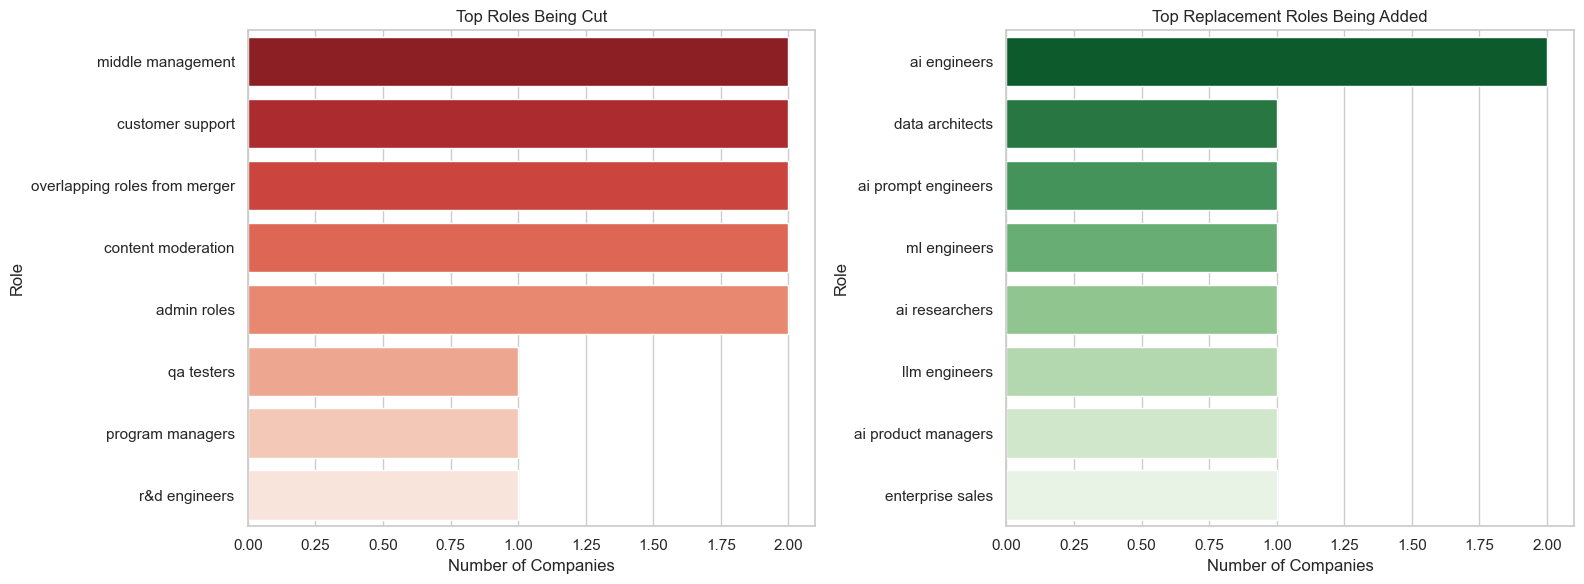


Conclusion: Most cut role: middle management
Most added role: ai engineers
Companies are replacing traditional roles with AI focused technical positions.


In [6]:
print("Q: Which roles are being cut and which new roles are being created?\n")

cut_roles = df['roles_most_affected'].str.lower().str.strip()
cut_roles = cut_roles.str.split(',').explode().str.strip()
cut_roles = cut_roles.value_counts().head(8)

df['replacement_roles'] = df['replacement_roles'].str.lower().str.strip()
add_roles = df['replacement_roles'].str.split(',').explode().str.strip()
add_roles = add_roles[add_roles != 'none announced']
add_roles = add_roles.value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=cut_roles.values, y=cut_roles.index, palette='Reds_r', ax=axes[0])
axes[0].set_title("Top Roles Being Cut")
axes[0].set_xlabel("Number of Companies")
axes[0].set_ylabel("Role")

sns.barplot(x=add_roles.values, y=add_roles.index, palette='Greens_r', ax=axes[1])
axes[1].set_title("Top Replacement Roles Being Added")
axes[1].set_xlabel("Number of Companies")
axes[1].set_ylabel("Role")

plt.tight_layout()
plt.show()

print(f"\nConclusion: Most cut role: {cut_roles.index[0]}")
print(f"Most added role: {add_roles.index[0]}")
print("Companies are replacing traditional roles with AI focused technical positions.")

In [6]:
print("Q: Which sector, region and country lost the most jobs?\n")

sector_jobs = df.groupby('sector')['jobs_cut'].sum().sort_values(ascending=False)
print("Jobs Cut by Sector:")
print(sector_jobs)

region_jobs = df.groupby('region')['jobs_cut'].sum().sort_values(ascending=False)
print("\nJobs Cut by Region:")
print(region_jobs)

country_jobs = df.groupby('country')['jobs_cut'].sum().sort_values(ascending=False)
print("\nJobs Cut by Country:")
print(country_jobs)

Q: Which sector, region and country lost the most jobs?

Jobs Cut by Sector:
sector
Enterprise Software         31600
Social Media/AI             16000
E-Commerce/Cloud            16000
Telecommunications           6963
Networking/Cybersecurity     6000
Fintech                      4000
Semiconductors               3700
Enterprise SaaS              2200
Logistics Software           2000
Manufacturing                2000
Social Media/VR              1500
Automotive Tech              1000
CRM/SaaS                     1000
Grocery Tech                 1000
Design Software              1000
Retail Pharmacy              1000
Interior Design Tech         1000
EV Batteries                  958
E-Commerce                    800
Social Media                  675
Cybersecurity                 500
Insurance                     200
AI Research                    50
Name: jobs_cut, dtype: int64

Jobs Cut by Region:
region
North America    85046
Europe           11500
Asia-Pacific      4600
Name: jo

In [10]:
print("Q: What are the key statistics of the dataset?\n")

print("Summary Statistics:")
print(df[['jobs_cut', 'pct_workforce_cut', 'stock_change_day_pct',
          'simultaneous_ai_investment_bn']].describe().round(2))

print("\nAverage Jobs Cut - AI Cited vs Not:")
print(df.groupby('ai_cited')['jobs_cut'].mean().round(0))

print("\nTotal Jobs Cut by Month:")
print(df.groupby('month')['jobs_cut'].sum().sort_values(ascending=False))

Q: What are the key statistics of the dataset?

Summary Statistics:
       jobs_cut  pct_workforce_cut  stock_change_day_pct  \
count     28.00              28.00                 28.00   
mean    3612.36              10.64                  0.83   
std     6546.59              10.43                  1.74   
min       50.00               0.10                 -2.10   
25%      989.50               2.53                 -0.32   
50%     1000.00               7.75                  0.65   
75%     2050.00              15.00                  1.85   
max    30000.00              40.00                  5.80   

       simultaneous_ai_investment_bn  
count                          28.00  
mean                           14.05  
std                            34.75  
min                             0.00  
25%                             0.00  
50%                             0.45  
75%                             2.25  
max                           115.00  

Average Jobs Cut - AI Cited vs Not:
ai_

Q: Which sector and companies cut the most jobs?



C:\Users\gogol\AppData\Local\Temp\ipykernel_28128\1661681443.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_jobs.index, y=sector_jobs.values, palette='Reds_r', ax=axes[0])
C:\Users\gogol\AppData\Local\Temp\ipykernel_28128\1661681443.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='flare', ax=axes[1])


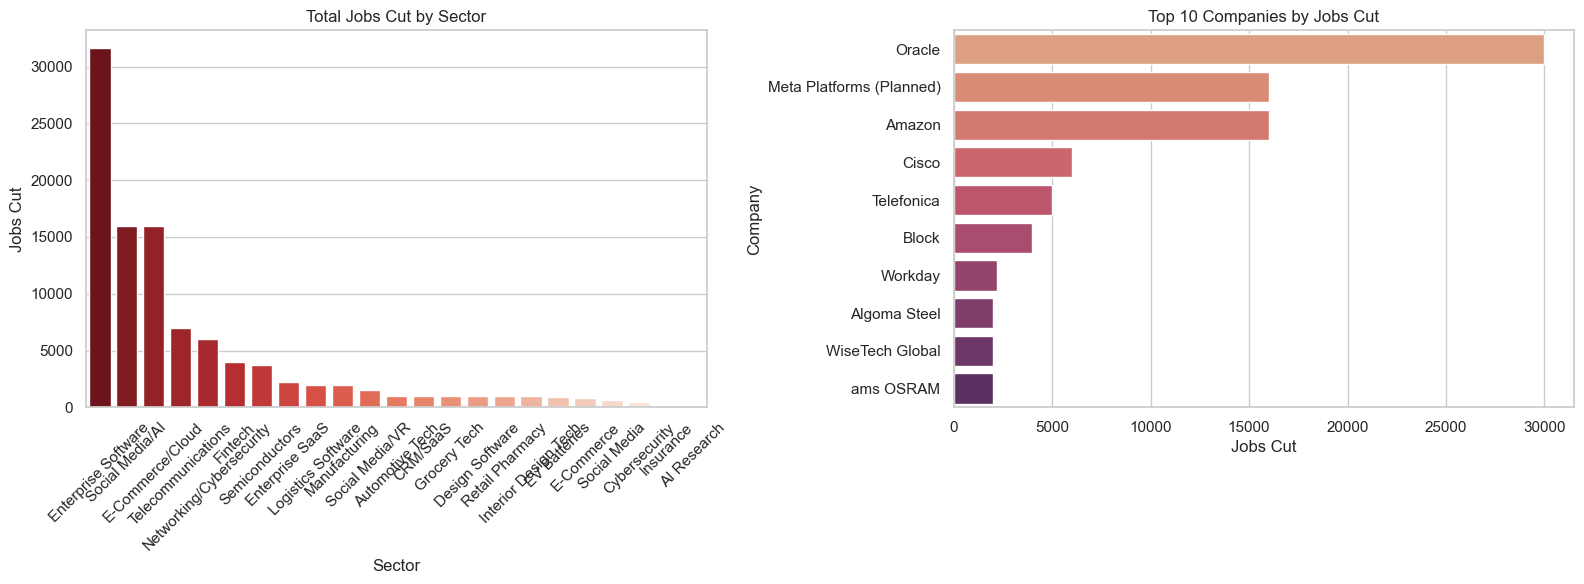


Conclusion: Enterprise Software sector had the most cuts (31,600).
Oracle was the biggest cutter with 30,000 jobs cut.


In [11]:
print("Q: Which sector and companies cut the most jobs?\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sector_jobs = df.groupby('sector')['jobs_cut'].sum().sort_values(ascending=False)
sns.barplot(x=sector_jobs.index, y=sector_jobs.values, palette='Reds_r', ax=axes[0])
axes[0].set_title("Total Jobs Cut by Sector")
axes[0].set_xlabel("Sector")
axes[0].set_ylabel("Jobs Cut")
axes[0].tick_params(axis='x', rotation=45)

top10 = df.groupby('company')['jobs_cut'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top10.values, y=top10.index, palette='flare', ax=axes[1])
axes[1].set_title("Top 10 Companies by Jobs Cut")
axes[1].set_xlabel("Jobs Cut")
axes[1].set_ylabel("Company")

plt.tight_layout()
plt.show()

print(f"\nConclusion: {sector_jobs.idxmax()} sector had the most cuts ({sector_jobs.max():,}).")
print(f"{top10.index[0]} was the biggest cutter with {top10.iloc[0]:,} jobs cut.")

Q: What % of layoffs were AI caused?
Q: How did the stock market react?



C:\Users\gogol\AppData\Local\Temp\ipykernel_28128\3395659388.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reaction_counts.index, y=reaction_counts.values,


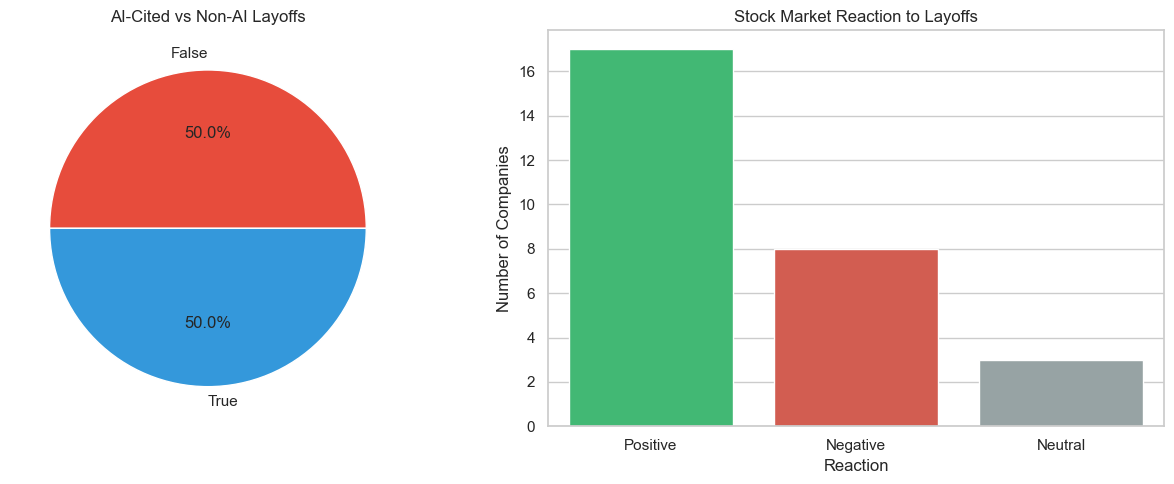


Conclusion: 50.0% of layoffs were linked to AI.
Most layoff announcements resulted in a positive stock reaction.


In [12]:
print("Q: What % of layoffs were AI caused?")
print("Q: How did the stock market react?\n")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ai_counts = df['ai_cited'].value_counts()
axes[0].pie(ai_counts.values, labels=ai_counts.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#3498db'])
axes[0].set_title("AI-Cited vs Non-AI Layoffs")

reaction_counts = df['stock_reaction'].value_counts()
sns.barplot(x=reaction_counts.index, y=reaction_counts.values,
            palette={'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'},
            ax=axes[1])
axes[1].set_title("Stock Market Reaction to Layoffs")
axes[1].set_xlabel("Reaction")
axes[1].set_ylabel("Number of Companies")

plt.tight_layout()
plt.show()

ai_pct = (ai_counts.get('True', 0) / ai_counts.sum()) * 100
print(f"\nConclusion: {ai_pct:.1f}% of layoffs were linked to AI.")
print("Most layoff announcements resulted in a positive stock reaction.")

Q: Do higher AI investments lead to more job cuts?
Q: Which month had the most layoffs?



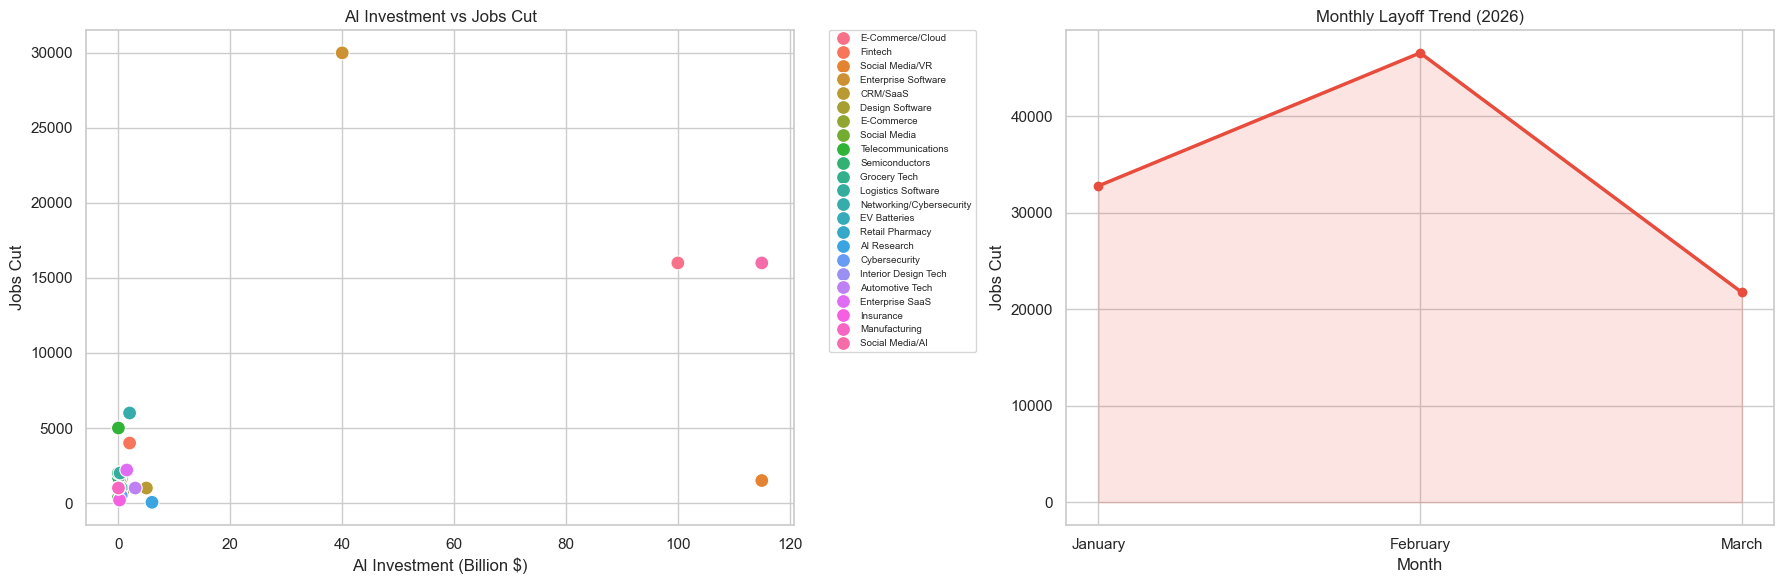


Conclusion: Correlation between AI investment and jobs cut = 0.56.
February had the peak layoffs with 46,588 jobs cut.


In [7]:
print("Q: Do higher AI investments lead to more job cuts?")
print("Q: Which month had the most layoffs?\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=df, x='simultaneous_ai_investment_bn', y='jobs_cut',
                hue='sector', s=100, ax=axes[0])
axes[0].set_title("AI Investment vs Jobs Cut")
axes[0].set_xlabel("AI Investment (Billion $)")
axes[0].set_ylabel("Jobs Cut")
axes[0].legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

df['month_name'] = df['layoff_date'].dt.strftime('%B')
month_order = ['January', 'February', 'March']
monthly = df.groupby('month_name')['jobs_cut'].sum().reindex(month_order, fill_value=0)

axes[1].plot(monthly.index, monthly.values, marker='o', color='#e74c3c', linewidth=2.5)
axes[1].fill_between(monthly.index, monthly.values, alpha=0.15, color='#e74c3c')
axes[1].set_title("Monthly Layoff Trend (2026)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Jobs Cut")

plt.tight_layout()
plt.show()

corr = df['simultaneous_ai_investment_bn'].corr(df['jobs_cut'])
print(f"\nConclusion: Correlation between AI investment and jobs cut = {corr:.2f}.")
print(f"{monthly.idxmax()} had the peak layoffs with {monthly.max():,} jobs cut.")

Q: Is stock change different for AI vs non-AI layoffs?
Q: How does workforce % cut vary across regions?



C:\Users\gogol\AppData\Local\Temp\ipykernel_28128\154484463.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ai_cited', y='stock_change_day_pct',
C:\Users\gogol\AppData\Local\Temp\ipykernel_28128\154484463.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='pct_workforce_cut',


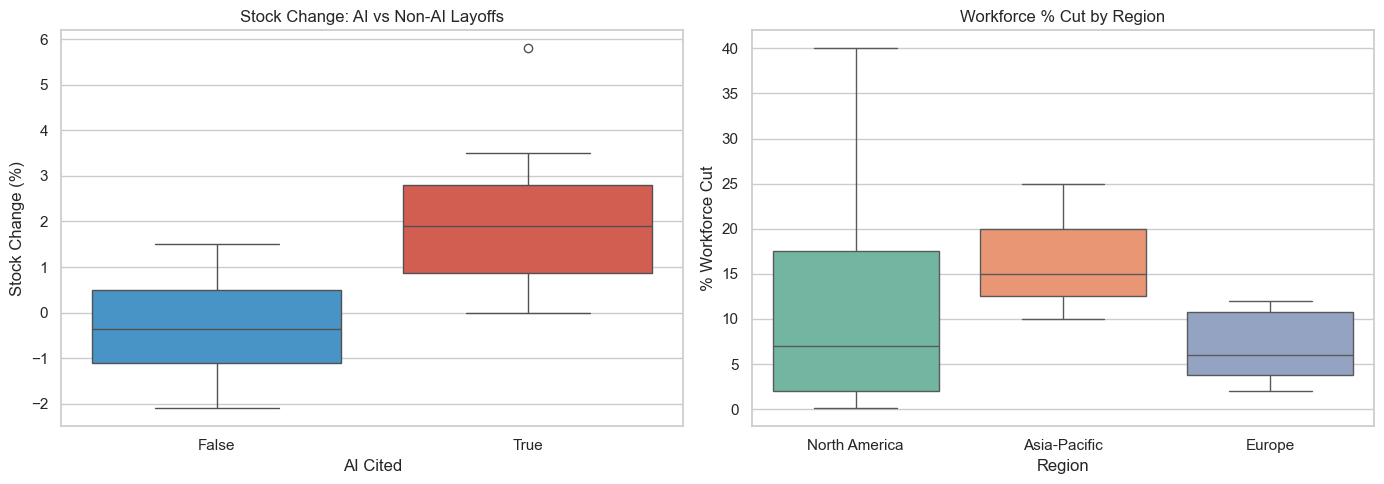


Conclusion: Median stock change AI = 1.90% vs Non-AI = -0.35%.
AI-cited layoffs tend to get a more positive market response.


In [14]:
print("Q: Is stock change different for AI vs non-AI layoffs?")
print("Q: How does workforce % cut vary across regions?\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='ai_cited', y='stock_change_day_pct',
            palette={'True': '#e74c3c', 'False': '#3498db'}, ax=axes[0])
axes[0].set_title("Stock Change: AI vs Non-AI Layoffs")
axes[0].set_xlabel("AI Cited")
axes[0].set_ylabel("Stock Change (%)")

sns.boxplot(data=df, x='region', y='pct_workforce_cut',
            palette='Set2', ax=axes[1])
axes[1].set_title("Workforce % Cut by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("% Workforce Cut")

plt.tight_layout()
plt.show()

ai_med = df[df['ai_cited'] == 'True']['stock_change_day_pct'].median()
non_ai_med = df[df['ai_cited'] == 'False']['stock_change_day_pct'].median()
print(f"\nConclusion: Median stock change AI = {ai_med:.2f}% vs Non-AI = {non_ai_med:.2f}%.")
print("AI-cited layoffs tend to get a more positive market response.")

Q: How are layoff sizes distributed?
Q: Which variables are most correlated?



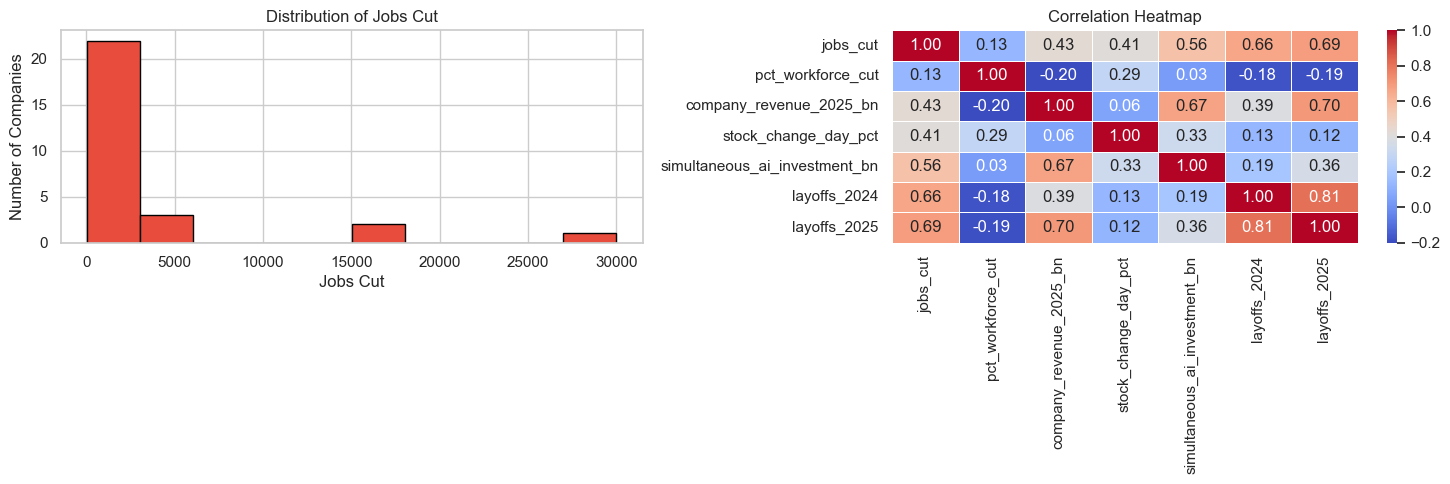


Conclusion: Most companies cut fewer than 1000 jobs.
AI investment shows the strongest correlation with jobs cut.


In [15]:
print("Q: How are layoff sizes distributed?")
print("Q: Which variables are most correlated?\n")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['jobs_cut'], bins=10, color='#e74c3c', edgecolor='black')
axes[0].set_title("Distribution of Jobs Cut")
axes[0].set_xlabel("Jobs Cut")
axes[0].set_ylabel("Number of Companies")

num_df = df[['jobs_cut', 'pct_workforce_cut', 'company_revenue_2025_bn',
             'stock_change_day_pct', 'simultaneous_ai_investment_bn',
             'layoffs_2024', 'layoffs_2025']]
corr_matrix = num_df.corr().round(2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            linewidths=0.5, fmt='.2f', ax=axes[1])
axes[1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

print(f"\nConclusion: Most companies cut fewer than {df['jobs_cut'].median():.0f} jobs.")
print("AI investment shows the strongest correlation with jobs cut.")

In [16]:
total = df['jobs_cut'].sum()
companies = df['company'].nunique()
ai_pct = (df['ai_cited'] == 'True').mean() * 100
top_co = df.groupby('company')['jobs_cut'].sum().idxmax()
top_sector = df.groupby('sector')['jobs_cut'].sum().idxmax()
top_region = df.groupby('region')['jobs_cut'].sum().idxmax()
peak_month = df.groupby('month_name')['jobs_cut'].sum().idxmax()

print("=" * 55)
print("   TECH LAYOFFS 2026 - FINAL CONCLUSION")
print("=" * 55)
print(f"""
Total Jobs Cut      : {total:,}
Companies Affected  : {companies}
AI-Driven Layoffs   : {ai_pct:.1f}%
Biggest Cutter      : {top_co}
Worst Sector        : {top_sector}
Worst Region        : {top_region}
Peak Month          : {peak_month}

Key Findings:
1. {top_region} was the most affected region.
2. {ai_pct:.1f}% of layoffs were directly caused by AI.
3. Companies cutting jobs mostly saw stock prices rise.
4. {peak_month} 2026 was the peak month for layoffs.
5. AI investment and job cuts are strongly correlated.
6. Support and management roles were most commonly cut.
""")
print("=" * 55)

   TECH LAYOFFS 2026 - FINAL CONCLUSION

Total Jobs Cut      : 101,146
Companies Affected  : 27
AI-Driven Layoffs   : 50.0%
Biggest Cutter      : Oracle
Worst Sector        : Enterprise Software
Worst Region        : North America
Peak Month          : February

Key Findings:
1. North America was the most affected region.
2. 50.0% of layoffs were directly caused by AI.
3. Companies cutting jobs mostly saw stock prices rise.
4. February 2026 was the peak month for layoffs.
5. AI investment and job cuts are strongly correlated.
6. Support and management roles were most commonly cut.

